<div class="alert alert-danger" role="alert">
<h1 align="center"><font size = 14>Deep-Learning (Part1)</font></h1>
<h4 align="center">Aug, 08_2026<h4>
<h3 align="center">Armin Amani</h3>

<div class="alert alert-danger" role="alert">
📤 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

<div class="alert alert-danger" role="alert"> 
💾 Read Data

In [2]:
df = pd.read_csv('House_Price_dataset.csv')
df

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168441,17355248,6754,https://www.zameen.com/Property/gulshan_e_maym...,House,26500000,Gadap Town,Karachi,Sindh,25.029909,67.137192,0,9.6 Marla,For Sale,6,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,9.6,5-10 Marla
168442,17355249,680,https://www.zameen.com/Property/gadap_town_gul...,House,12500000,Gadap Town,Karachi,Sindh,25.017951,67.136393,0,8 Marla,For Sale,3,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,8.0,5-10 Marla
168443,17355250,6757,https://www.zameen.com/Property/gulshan_e_maym...,House,27000000,Gadap Town,Karachi,Sindh,25.015384,67.116330,0,9.6 Marla,For Sale,6,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,9.6,5-10 Marla
168444,17355251,6752,https://www.zameen.com/Property/gulshan_e_maym...,House,11000000,Gadap Town,Karachi,Sindh,25.013265,67.120818,0,7.8 Marla,For Sale,3,07-18-2019,Al Shahab Enterprises,Shahmir,Marla,7.8,5-10 Marla


In [3]:
df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
 17  Area Type      168446 non-nul

In [5]:
df.isnull().sum()

property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           44071
agent            44072
Area Type            0
Area Size            0
Area Category        0
dtype: int64

* **we have null data in agency and agent**

<div class="alert alert-danger" role="alert"> 
🔎 we just use these columns:
price, latitude, longitude, baths, bedrooms, Area Size

In [6]:
df_new = df[['latitude', 'longitude', 'baths', 'bedrooms', 'Area Size', 'price']]
df_new

,latitude,longitude,baths,bedrooms,Area Size,price
0,33.679890,73.012640,2,2,4.0,10000000
1,33.700993,72.971492,3,3,5.6,6900000
2,33.631486,72.926559,6,5,8.0,16500000
3,33.707573,73.151199,4,4,2.0,43500000
4,33.492591,73.301339,3,3,8.0,7000000
...,...,...,...,...,...,...
168441,25.029909,67.137192,0,6,9.6,26500000
168442,25.017951,67.136393,0,3,8.0,12500000
168443,25.015384,67.116330,0,6,9.6,27000000
168444,25.013265,67.120818,0,3,7.8,11000000


<div class="alert alert-danger" role="alert"> 
🔎 Outliers of DataFrame

In [7]:
def OUTLIERS(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    ub = (Q3 + (1.5 * IQR))
    lb = (Q1 - (1.5 * IQR))
    
    return ub, lb

In [8]:
def BOXPLOT(df, feature):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    sns.boxplot(data=df, x=df[feature], ax=ax)
    ub = OUTLIERS(df, feature)[0]
    lb = OUTLIERS(df, feature)[1]
    ax.axvline(x=ub, color='b', label=f'upper_{feature}')
    ax.axvline(x=lb, color='r', label=f'lower_{feature}')
    
    ax.set_title(f'Box Plot of {feature}')
    ax.legend()
    plt.show()


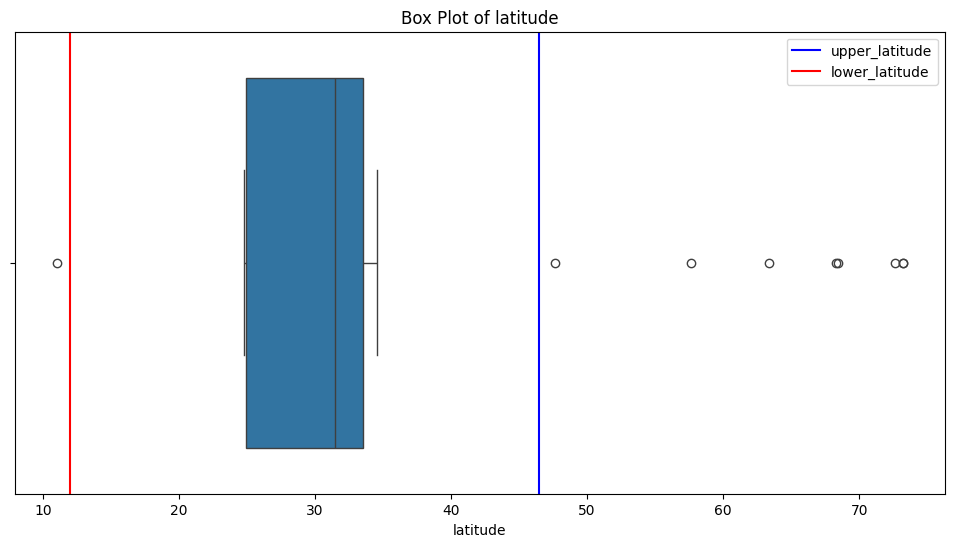

In [9]:
BOXPLOT(df_new, 'latitude')

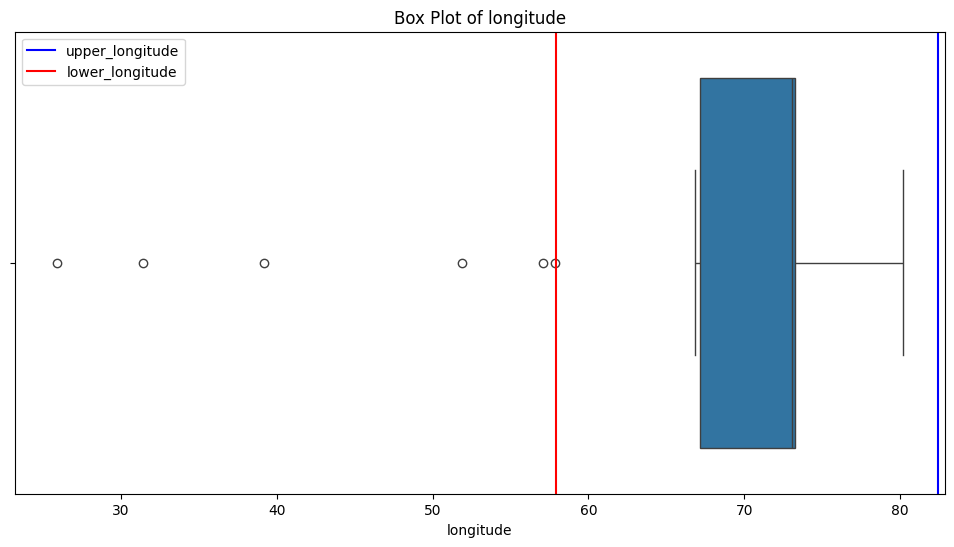

In [10]:
BOXPLOT(df_new, 'longitude')

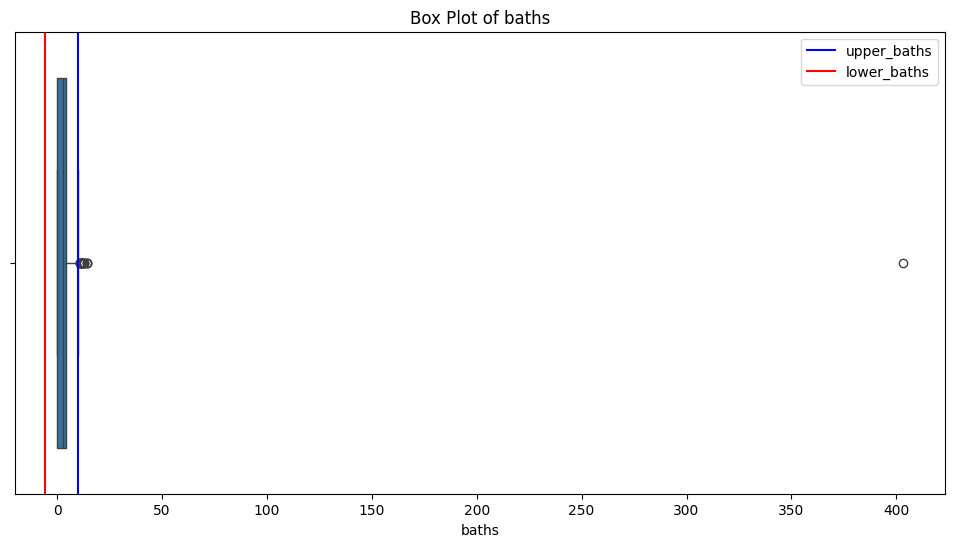

In [11]:
BOXPLOT(df_new, 'baths')

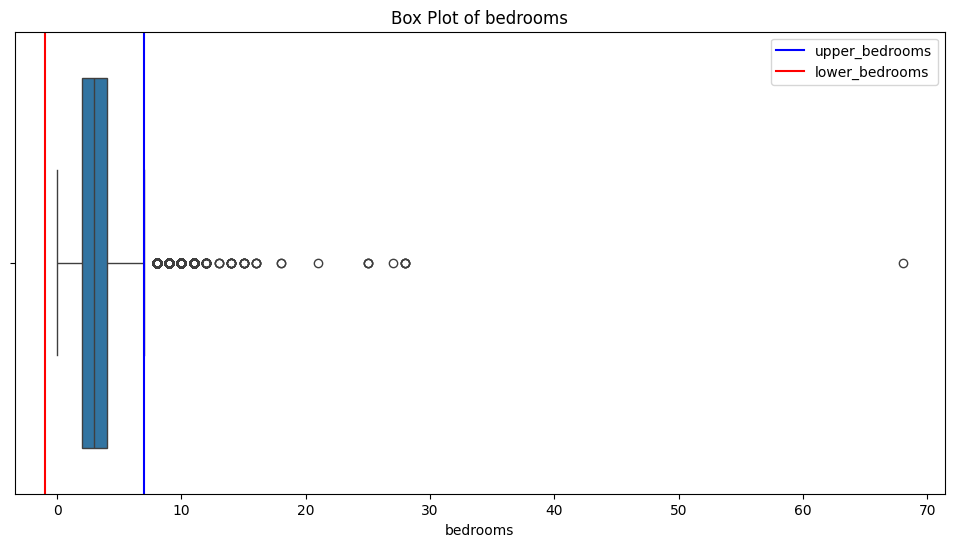

In [12]:
BOXPLOT(df_new, 'bedrooms')

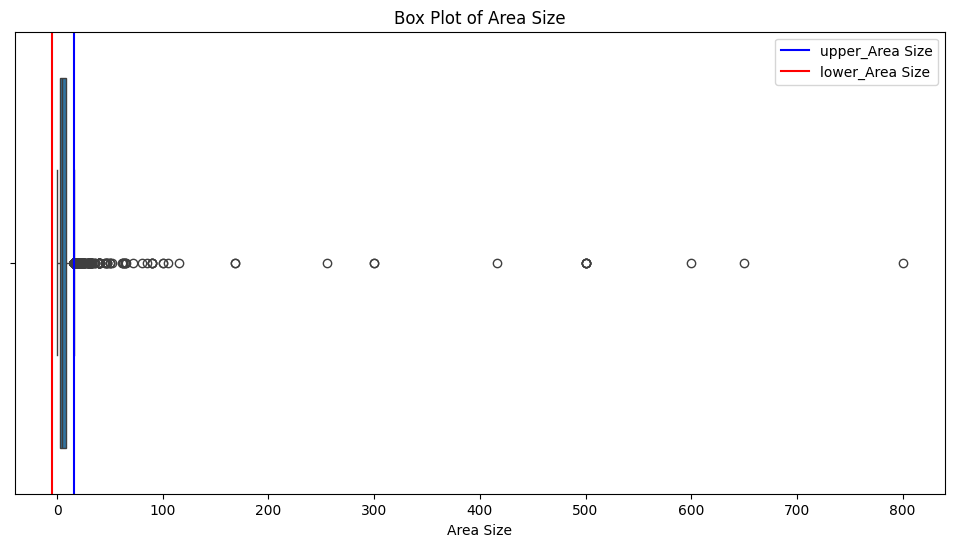

In [13]:
BOXPLOT(df_new, 'Area Size')

In [14]:
def DROP_OUTLIERS(df, features):
    ubs = OUTLIERS(df, features)[0]
    lbs = OUTLIERS(df, features)[1]
    
    for i, feature in enumerate(features):
        df = df.drop(index=df[df[feature] > ubs[i]].index, axis=0)
        df = df.drop(index=df[df[feature] < lbs[i]].index, axis=0)
    
    return df

In [15]:
df_new = DROP_OUTLIERS(df_new, ['latitude', 'longitude', 'baths', 'bedrooms', 'Area Size'])

C:\Users\Beethoven\AppData\Local\Temp\ipykernel_12072\4144069911.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df = df.drop(index=df[df[feature] > ubs[i]].index, axis=0)
C:\Users\Beethoven\AppData\Local\Temp\ipykernel_12072\4144069911.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df = df.drop(index=df[df[feature] < lbs[i]].index, axis=0)


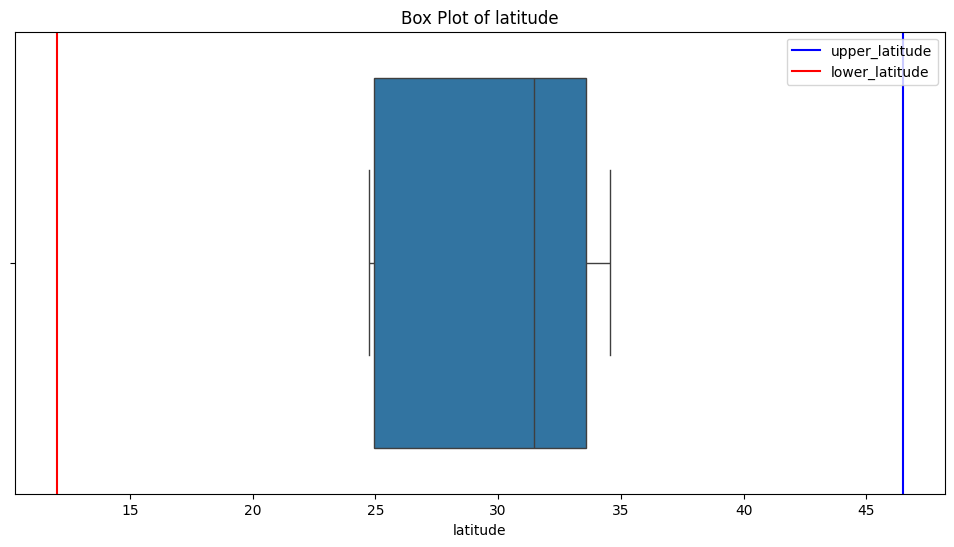

In [16]:
BOXPLOT(df_new, 'latitude')

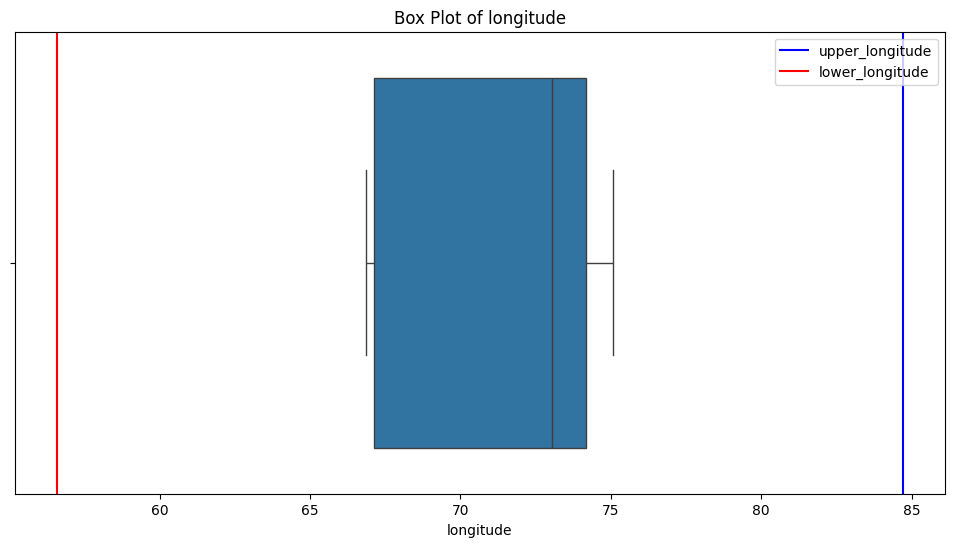

In [17]:
BOXPLOT(df_new, 'longitude')

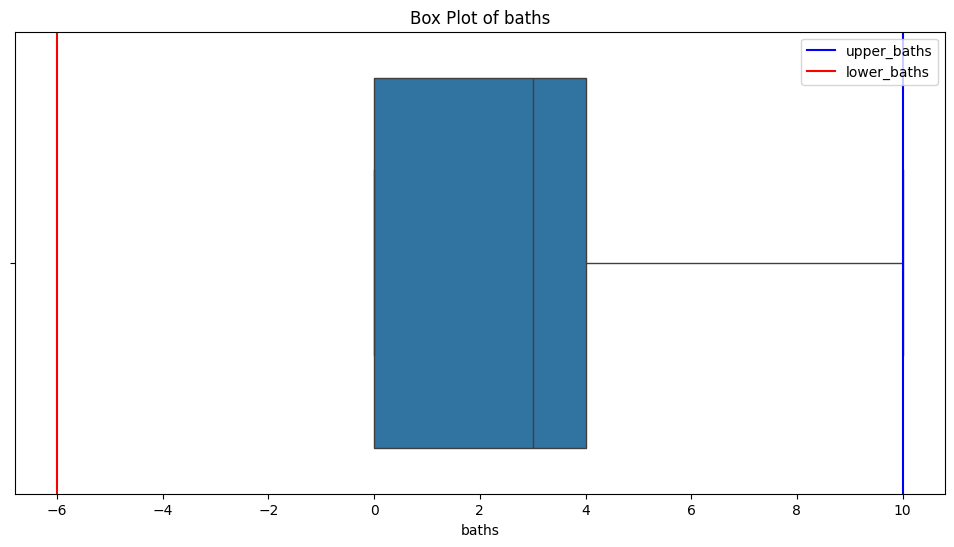

In [18]:
BOXPLOT(df_new, 'baths')

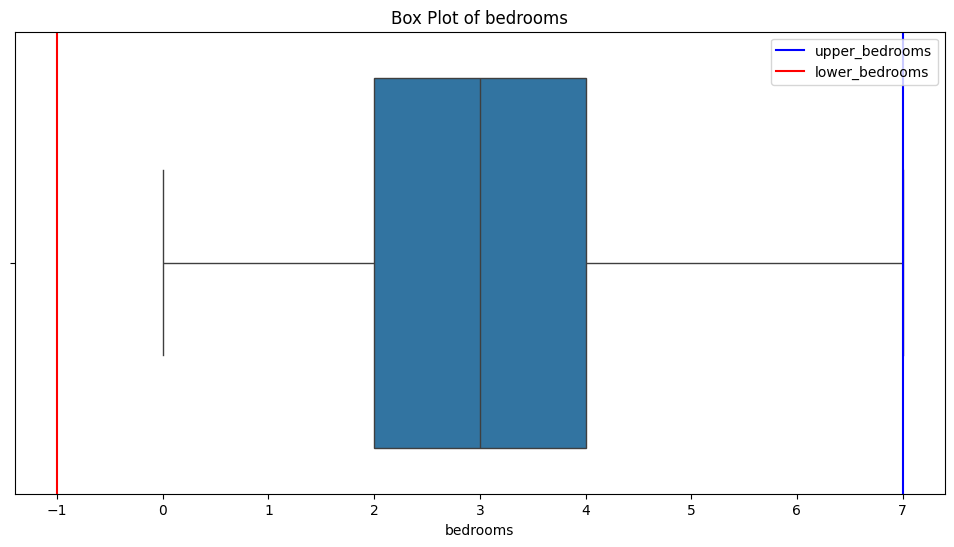

In [19]:
BOXPLOT(df_new, 'bedrooms')

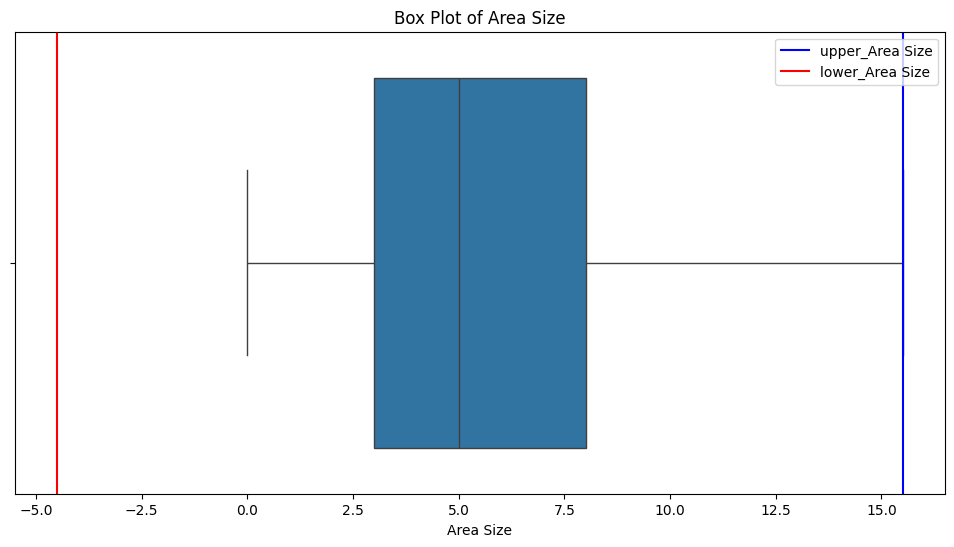

In [20]:
BOXPLOT(df_new, 'Area Size')

In [21]:
df_new

,latitude,longitude,baths,bedrooms,Area Size,price
0,33.679890,73.012640,2,2,4.0,10000000
1,33.700993,72.971492,3,3,5.6,6900000
2,33.631486,72.926559,6,5,8.0,16500000
3,33.707573,73.151199,4,4,2.0,43500000
4,33.492591,73.301339,3,3,8.0,7000000
...,...,...,...,...,...,...
168441,25.029909,67.137192,0,6,9.6,26500000
168442,25.017951,67.136393,0,3,8.0,12500000
168443,25.015384,67.116330,0,6,9.6,27000000
168444,25.013265,67.120818,0,3,7.8,11000000


<div class="alert alert-danger" role="alert"> 
🔎 split x & y

In [22]:
x = df_new.drop('price', axis=1)
x

,latitude,longitude,baths,bedrooms,Area Size
0,33.679890,73.012640,2,2,4.0
1,33.700993,72.971492,3,3,5.6
2,33.631486,72.926559,6,5,8.0
3,33.707573,73.151199,4,4,2.0
4,33.492591,73.301339,3,3,8.0
...,...,...,...,...,...
168441,25.029909,67.137192,0,6,9.6
168442,25.017951,67.136393,0,3,8.0
168443,25.015384,67.116330,0,6,9.6
168444,25.013265,67.120818,0,3,7.8


In [23]:
y = df_new['price']
y

0         10000000
1          6900000
2         16500000
3         43500000
4          7000000
            ...   
168441    26500000
168442    12500000
168443    27000000
168444    11000000
168445     9000000
Name: price, Length: 161994, dtype: int64

In [24]:
y = np.reshape(y, (-1, 1))
y.shape

(161994, 1)

<div class="alert alert-danger" role="alert"> 
🔎 split train & test set

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)

In [26]:
print(f"shape of x_train is : {x_train.shape}")
print(f"shape of x_test is : {x_test.shape}")
print(f"shape of y_train is : {y_train.shape}")
print(f"shape of y_test is : {y_test.shape}")

shape of x_train is : (113395, 5)
shape of x_test is : (48599, 5)
shape of y_train is : (113395, 1)
shape of y_test is : (48599, 1)


<div class="alert alert-danger" role="alert"> 
🔎 scalling operation on features

In [27]:
scaler = StandardScaler()
scaler

StandardScaler()

In [28]:
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [29]:
x_train_s

array([[-1.33947528, -1.35722834,  0.0966401 ,  0.53422317, -0.47429147],
       [ 0.99920817,  0.57528057, -1.29232907, -0.02948408, -1.28268245],
       [-1.34616694, -1.36009616,  0.0966401 , -0.59319134, -0.47429147],
       ...,
       [ 0.39140271,  0.92884452,  0.55962982, -0.02948408, -0.1855804 ],
       [ 1.00626038,  0.545318  , -1.29232907, -0.02948408,  1.25797492],
       [-1.27585151, -1.27250827,  0.0966401 , -0.02948408,  0.68055279]])

<div class="alert alert-danger" role="alert"> 
🔎 build the neural network model

In [30]:
model1 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(x_train_s.shape[1], activation='relu', input_shape=(x_train_s.shape[1], )),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1,)
])

In [31]:
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 5)                 30        
                                                                 
 dense_1 (Dense)             (None, 64)                384       
                                                                 
 dense_2 (Dense)             (None, 16)                1040      
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1,471
Trainable params: 1,471
Non-trainable params: 0
_________________________________________________________________


In [32]:
model2 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(x_train_s.shape[1], activation='relu', input_shape=(x_train_s.shape[1], )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1,)
])



In [33]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 5)                 30        
                                                                 
 dropout (Dropout)           (None, 5)                 0         
                                                                 
 dense_5 (Dense)             (None, 64)                384       
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_7 (Dense)             (None, 16)               

<div class="alert alert-danger" role="alert"> 
🔎 compile the model

* **In summary, the loss function is the primary objective that the model is trying to minimize, while the metrics provide additional performance measures that can be used to evaluate the model's performance during training and inference.**

In [34]:
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='mse', metrics=['mae'])

In [35]:
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

<div class="alert alert-danger" role="alert"> 
🔎 train the model

In [36]:
history1 = model1.fit(x_train_s, y_train, epochs=300, validation_split=0.3, batch_size=16)

Epoch 1/300
4961/4961 [==============================] - 8s 1ms/step - loss: 767882371792896.0000 - mae: 12239654.0000 - val_loss: 816816343482368.0000 - val_mae: 11364332.0000
Epoch 2/300
4961/4961 [==============================] - 5s 1ms/step - loss: 741522949537792.0000 - mae: 11726946.0000 - val_loss: 812113354293248.0000 - val_mae: 11893892.0000
Epoch 3/300
4961/4961 [==============================] - 5s 1ms/step - loss: 736639504613376.0000 - mae: 11687145.0000 - val_loss: 825525194981376.0000 - val_mae: 12455006.0000
Epoch 4/300
4961/4961 [==============================] - 5s 1ms/step - loss: 733848916721664.0000 - mae: 11691359.0000 - val_loss: 812577613414400.0000 - val_mae: 11848292.0000
Epoch 5/300
4961/4961 [==============================] - 5s 1ms/step - loss: 734367869566976.0000 - mae: 11679972.0000 - val_loss: 807942337069056.0000 - val_mae: 11389574.0000
Epoch 6/300
4961/4961 [==============================] - 5s 1ms/step - loss: 729894191366144.0000 - mae: 11666150.0

In [37]:
history2 = model2.fit(x_train_s, y_train, epochs=500, validation_split=0.3, batch_size=32)

Epoch 1/500
2481/2481 [==============================] - 5s 2ms/step - loss: 1066226772082688.0000 - mae: 14740645.0000 - val_loss: 936299045322752.0000 - val_mae: 13206316.0000
Epoch 2/500
2481/2481 [==============================] - 4s 2ms/step - loss: 887902749851648.0000 - mae: 13976789.0000 - val_loss: 914728108949504.0000 - val_mae: 12923772.0000
Epoch 3/500
2481/2481 [==============================] - 4s 2ms/step - loss: 871327598641152.0000 - mae: 13753059.0000 - val_loss: 899303136559104.0000 - val_mae: 12871535.0000
Epoch 4/500
2481/2481 [==============================] - 4s 2ms/step - loss: 860208263856128.0000 - mae: 13646385.0000 - val_loss: 891632526295040.0000 - val_mae: 12693421.0000
Epoch 5/500
2481/2481 [==============================] - 4s 2ms/step - loss: 851490755313664.0000 - mae: 13539949.0000 - val_loss: 882108704751616.0000 - val_mae: 12675919.0000
Epoch 6/500
2481/2481 [==============================] - 4s 1ms/step - loss: 842124169838592.0000 - mae: 13499763.

<div class="alert alert-danger" role="alert"> 
🔎 evaluate the model

In [38]:
y_pred1 = model1.predict(x_test_s)
y_pred2 = model2.predict(x_test_s)

1519/1519 [==============================] - 1s 579us/step


In [39]:
r2_score_1 = r2_score(y_test, y_pred1)
r2_score_2 = r2_score(y_test, y_pred2)

In [40]:
df_of_r2_score = pd.DataFrame([r2_score_1, r2_score_2], index=['model1', 'model2'], columns=['R2_score'])
df_of_r2_score

,R2_score
model1,0.375090
model2,0.291993


<div class="alert alert-danger" role="alert"> 
⬛⬜⬛⬜⬛⬜ Plot

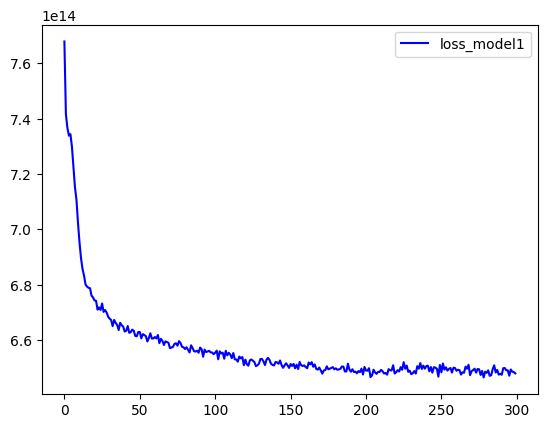

In [48]:
plt.plot(history1.history['loss'], color='b', label='loss_model1')
plt.legend()

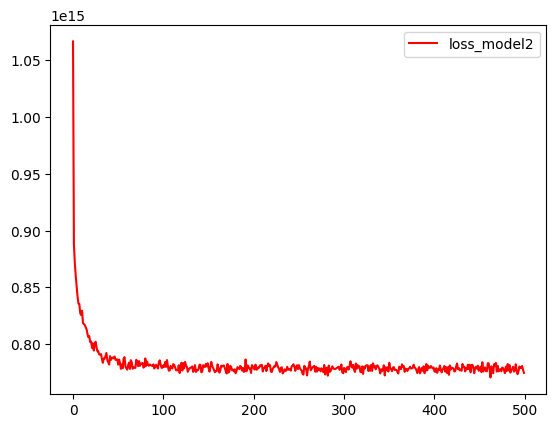

In [49]:
plt.plot(history2.history['loss'], color='r', label='loss_model2')
plt.legend()